In [ ]:
!python3 src/preprocessing/to-bronze/download_raw_data.py --ravdess --savee
!python3 src/preprocessing/to-silver/unify_audio.py --ravdess --savee
!python3 src/preprocessing/to-silver/enhance_audio.py --ravdess --savee
!python3 src/preprocessing/to-silver/chunk_audio.py --ravdess --savee

!python3 src/preprocessing/to-gold/01_extract_metadata.py --ravdess --gold-dir data/gold_ravdess
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --ravdess --metadata-path data/gold_ravdess/basic_features/metadata.parquet --gold-dir data/gold_ravdess
!python3 src/preprocessing/to-gold/03_extract_features_vggish.py --ravdess --metadata-path data/gold_ravdess/basic_features/metadata.parquet --gold-dir data/gold_ravdess
!python3 src/preprocessing/to-gold/04_extract_wav2vec2_features.py --ravdess --metadata-path data/gold_ravdess/basic_features/metadata.parquet --gold-dir data/gold_ravdess
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --ravdess --metadata-path data/gold_ravdess/basic_features/metadata.parquet --gold-dir data/gold_ravdess
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --ravdess --metadata-path data/gold_ravdess/basic_features/metadata.parquet --gold-dir data/gold_ravdess

!python3 src/preprocessing/to-gold/01_extract_metadata.py --savee --gold-dir data/gold_savee
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --savee --metadata-path data/gold_savee/basic_features/metadata.parquet --gold-dir data/gold_savee
!python3 src/preprocessing/to-gold/03_extract_features_vggish.py --savee --metadata-path data/gold_savee/basic_features/metadata.parquet --gold-dir data/gold_savee
!python3 src/preprocessing/to-gold/04_extract_wav2vec2_features.py --savee --metadata-path data/gold_savee/basic_features/metadata.parquet --gold-dir data/gold_savee
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --savee --metadata-path data/gold_savee/basic_features/metadata.parquet --gold-dir data/gold_savee
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --savee --metadata-path data/gold_savee/basic_features/metadata.parquet --gold-dir data/gold_savee

Завантаження SAVEE з KaggleHub...
Успішно скопійовано 0 файлів SAVEE до /workspace/data/bronze/savee

--- Обробка RAVDESS ---
RAVDESS: 100%|██████████████████████████████| 2880/2880 [01:01<00:00, 47.13it/s]
RAVDESS: Успішно оброблено 2112 цільових файлів.

--- Обробка SAVEE ---
SAVEE: 100%|██████████████████████████████████| 481/481 [00:26<00:00, 17.88it/s]
SAVEE: Успішно оброблено 420 цільових файлів.
Збір метаданих RAVDESS: 100%|█████████████| 1056/1056 [00:00<00:00, 6275.75it/s]

Створення DataFrame та збереження у Parquet...
Готово! Успішно збережено 1056 рядків (метаданих чанків).
Файл знаходиться тут: data/gold_ravdess/basic_features/metadata.parquet
Завантаження метаданих...
До обробки підготовлено 1056 аудіо-чанків.
Обчислення акустичних ознак: 100%|██████████| 1056/1056 [00:32<00:00, 32.61it/s]

Об'єднання метаданих з ознаками...
Готово! Успішно збережено 1056 рядків з 103 колонками.
Файл знаходиться тут: data/gold_ravdess/features.parquet
Завантаження метаданих...
До обробки 

In [ ]:
!python3 src/models/train_rcnn_lstm_attention.py --base-features "data/gold_ravdess/features.parquet,data/gold_savee/features.parquet" --hubert-features --speaker-dependent --experiment-name "Exp3_Combined" --run-name "CRNN_Combined" --n-trials 5 --epochs 50 --final-epochs 50

!python3 src/models/train_transformer_finetune.py --model-type hubert --base-features "data/gold_ravdess/features.parquet,data/gold_savee/features.parquet" --speaker-dependent --experiment-name "Exp3_Combined" --run-name "HuBERT_Combined" --n-trials 5 --epochs 30 --final-epochs 100

2026/03/22 16:07:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/22 16:07:55 INFO mlflow.store.db.utils: Updating database tables
2026/03/22 16:07:55 INFO mlflow.tracking.fluent: Experiment with name 'Exp3_Combined' does not exist. Creating a new experiment.
Використовується пристрій: cuda

1. Завантаження повного датасету...
Завантаження даних з data/gold_ravdess/features.parquet...
  Додавання ознак HuBERT...
  Додавання пре-обчислених Mel-спектрограм...
Завантаження даних з data/gold_savee/features.parquet...
  Додавання ознак HuBERT...
  Додавання пре-обчислених Mel-спектрограм...
Об'єднаний датасет готовий! Розмірність (рядки, колонки): (2037, 12903)
2. Відділення 15% даних як абсолютно недоторканий Test Set...
Дані для K-Fold CV (Optuna): 1731 записів
Дані для фінального тесту: 306 записів

3. Запуск Optuna 5-Fold CV HPO (5 trials)...
[I 2026-03-22 16:07:57,824] A new study created in memory with name: no-name-b606799b-3a03-4ac7-96d3-fa71dedc4793

In [5]:
!python3 src/models/train_transformer_finetune.py --model-type hubert --base-features "data/gold_ravdess/features.parquet,data/gold_savee/features.parquet" --speaker-dependent --experiment-name "Exp3_Combined" --run-name "HuBERT_Combined" --n-trials 5 --epochs 30 --final-epochs 100

Використовується пристрій: cuda

1. Завантаження базових метаданих...
Завантаження даних з data/gold_ravdess/features.parquet...
Завантаження даних з data/gold_savee/features.parquet...
Об'єднаний датасет готовий! Розмірність (рядки, колонки): (2037, 103)

--- Статистика розбиття (Speaker-Dependent / Random) ---
Train: 1425 записів (70.0%) | Акторів: 28
Val:   306 записів (15.0%) | Акторів: 28
Test:  306 записів (15.0%) | Акторів: 28
------------------------------------------------------------------------


2. Запуск Optuna HPO (5 trials по 30 епох)...
[I 2026-03-22 16:15:58,644] A new study created in memory with name: no-name-88214906-f20b-4a23-b7a5-1acea8aa732a
Попереднє завантаження 1425 аудіофайлів у пам'ять...
100%|██████████████████████████████████████| 1425/1425 [00:02<00:00, 564.67it/s]
Попереднє завантаження 306 аудіофайлів у пам'ять...
Loading weights: 100%|█████████████████████| 211/211 [00:00<00:00, 20660.15it/s]
HubertForSequenceClassification LOAD REPORT from: facebook/h

## Результати Експерименту 3 (RAVDESS + SAVEE) для моделі: CRNN_Combined

### 1. Матриця плутанини

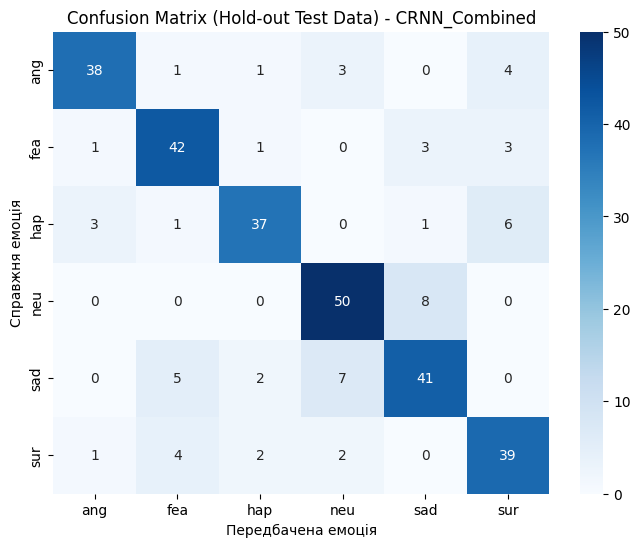

### 2. Графіки ROC-AUC

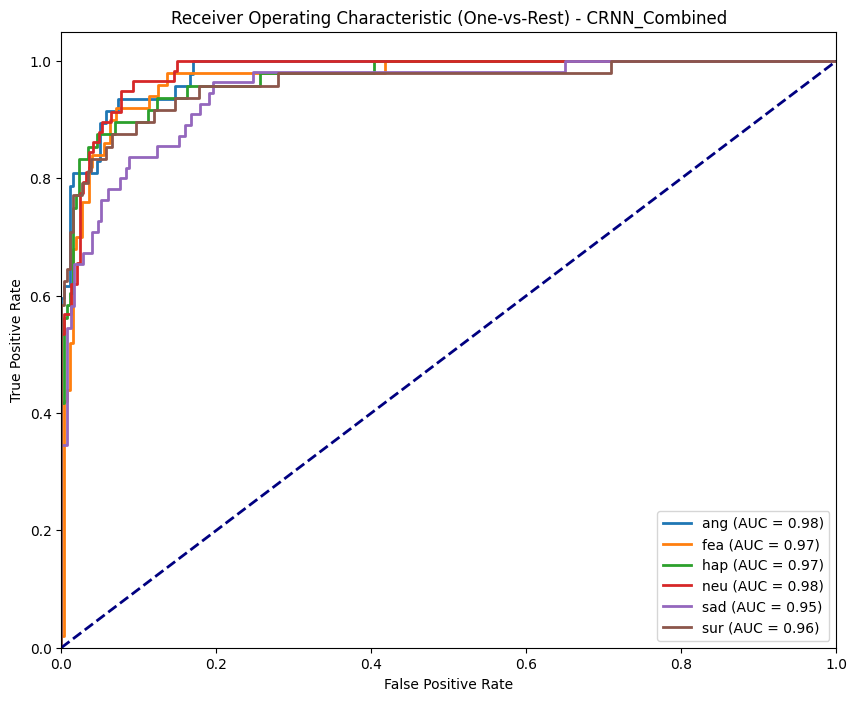

### 3. Криві навчання (Loss)

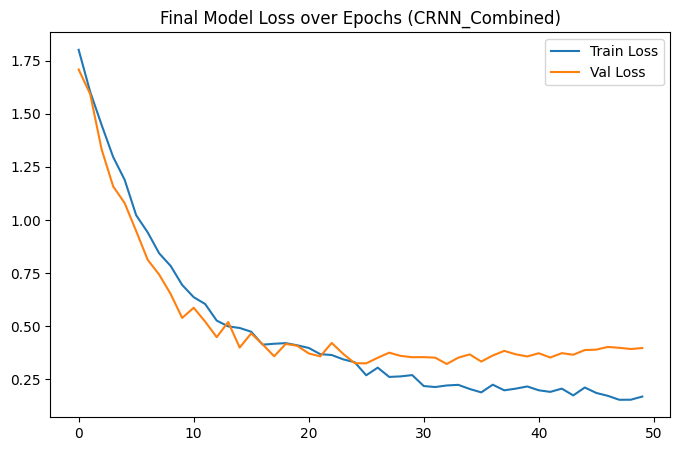

---

## Результати Експерименту 3 (RAVDESS + SAVEE) для моделі: HuBERT_Combined

### 1. Матриця плутанини

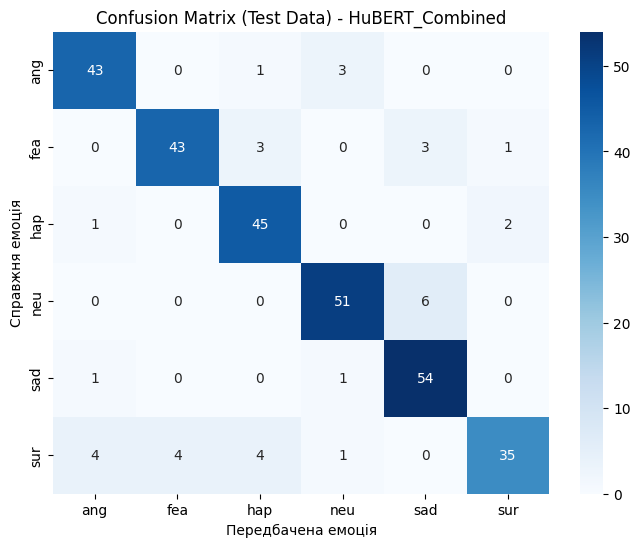

### 2. Графіки ROC-AUC

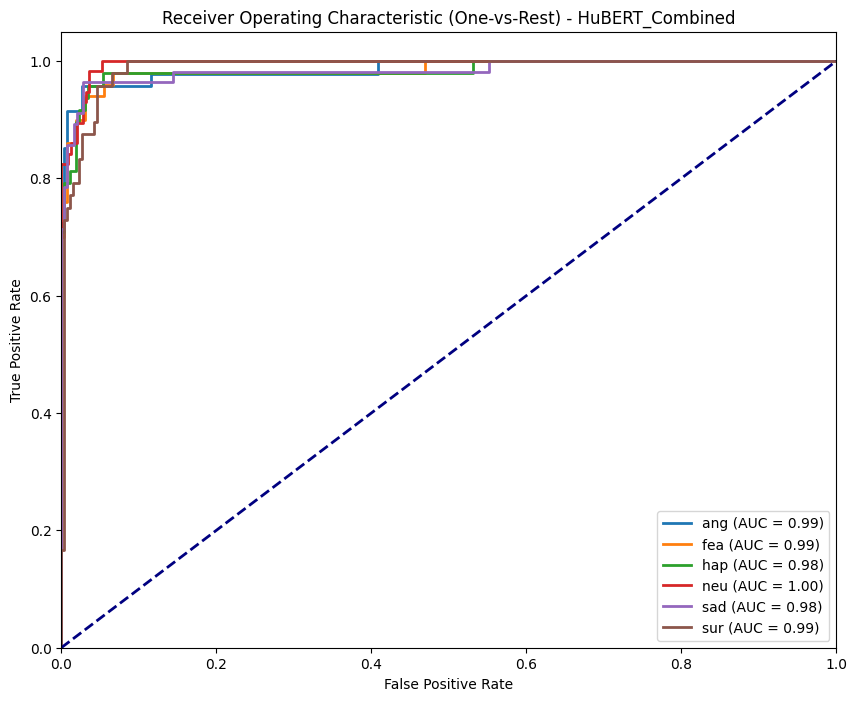

### 3. Криві навчання (Loss)

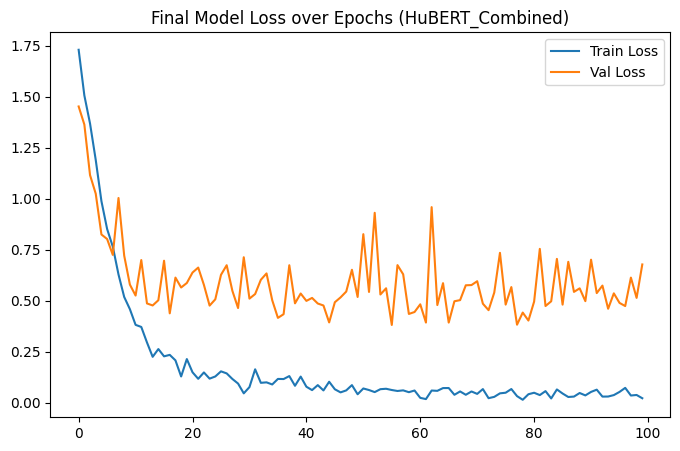

---

In [ ]:
from IPython.display import Image, display, Markdown
import os

run_names = ["CRNN_Combined", "HuBERT_Combined"]

for run in run_names:
    if os.path.exists(f"temp/{run}_confusion_matrix.png"):
        display(Markdown(f"## Результати Експерименту 3 (RAVDESS + SAVEE) для моделі: {run}"))
        
        display(Markdown("### 1. Матриця плутанини"))
        display(Image(filename=f"temp/{run}_confusion_matrix.png"))
        
        display(Markdown("### 2. Графіки ROC-AUC"))
        display(Image(filename=f"temp/{run}_roc_curve.png"))
        
        display(Markdown("### 3. Криві навчання (Loss)"))
        if os.path.exists(f"temp/{run}_learning_curves.png"):
            display(Image(filename=f"temp/{run}_learning_curves.png"))
        elif os.path.exists(f"temp/{run}_loss_curve.png"):
            display(Image(filename=f"temp/{run}_loss_curve.png"))
            
        display(Markdown("---"))
    else:
        print(f"Графіки для {run} не знайдені. Перевір, чи успішно завершилося навчання.")